# E3SM Diagnostics: Compare Customized Simulations against CMIP6

This notebook facilitates the comparison of RMSE metrics between your **customized E3SM simulations** and the **CMIP6 models distribution** (plotting both **AMIP** and **Historical** distributions side-by-side on the same chart).

All configurations and figure generation blocks are consolidated below for convenience.

In [51]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
import os
import sys
from pathlib import Path
from IPython.display import Image, display

# Set project root path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from workflows.e3sm_diags_compare import run_plot_comparison

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration and Execution Block
Specify your configurations and execute this cell to generate and display the comparison plots.

--- Generating side-by-side CMIP comparison plot ---
Reading E3SM Diags metrics from base directory: /global/cfs/cdirs/e3sm/www/zhan391/E3SMv3_S2D
Success! Comparison PNG created at: /global/cfs/cdirs/e3sm/www/zhan391/E3SMv3_S2D/cmip6_comparison.png


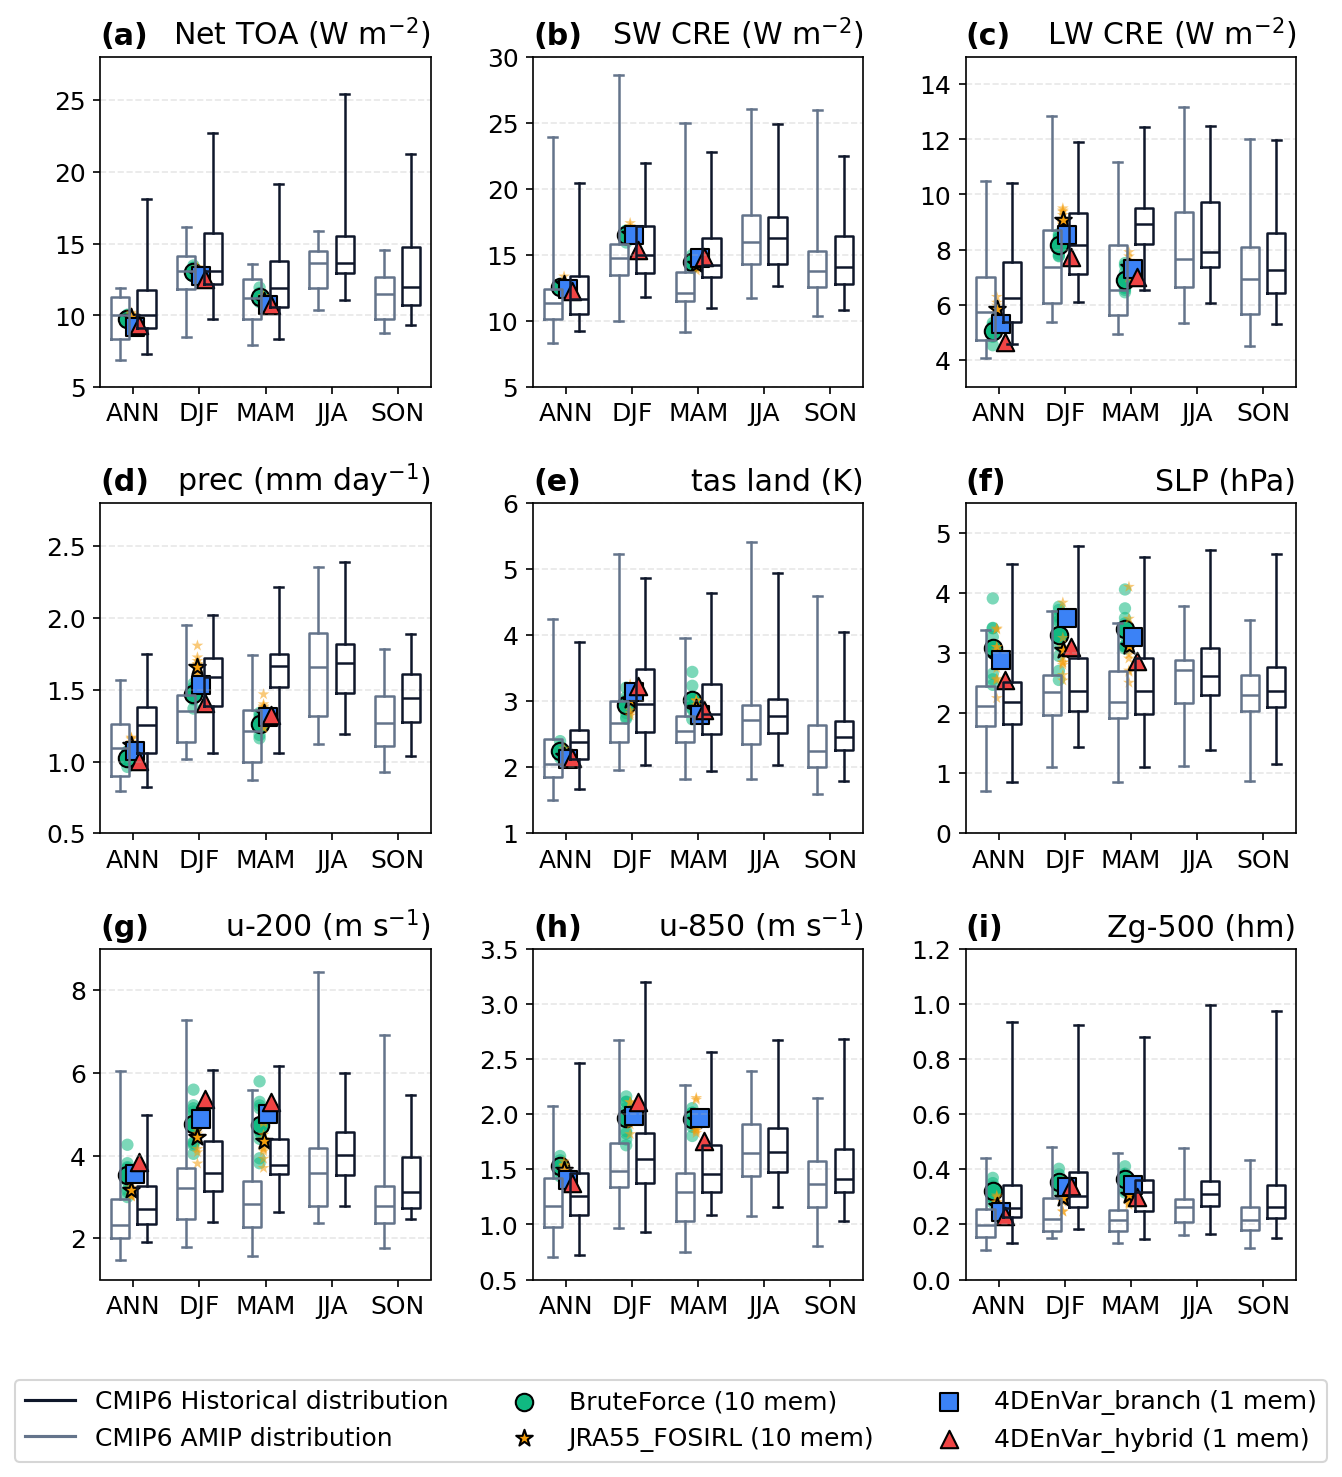

In [52]:
# ==========================================================
# INPUT PARAMETERS & SETUP
# ==========================================================
base_dir = "/global/cfs/cdirs/e3sm/www/zhan391/E3SMv3_S2D"
output_dir = "/global/cfs/cdirs/e3sm/www/zhan391/E3SMv3_S2D"

# Figure configuration parameters (edit these to control layout spacing, sizing, fonts, and colors)
figsize = [9, 10]
hspace = 0.35       # Vertical spacing between subplot rows
wspace = 0.15       # Horizontal spacing between subplot columns
whis = [0, 100]     # Whisker percentile range for CMIP6 box plots (e.g., [5, 95] or [0, 100])
box_width = 0.55    # Width of the box plots (larger is wider; e.g., try 0.35 to 0.45)
box_linewidth = 1.2 # Thickness of box plot outlines (e.g., 1.5 to 2.0)
member_size = 35    # Size of the E3SM ensemble member dots (e.g., 30 to 50)
member_alpha = 0.55 # Opacity of the E3SM ensemble member dots (e.g., 0.4 to 0.7)
mean_size = 70      # Size of the E3SM ensemble mean marker (e.g., 60 to 90)
fontz = 12         # Font size scaling for all labels, titles, ticks, and legends
colors = None       # Set to custom color list if desired, e.g. ['#10b981', '#f59e0b', ...]
markers = None      # Set to custom marker list if desired, e.g. ['o', '*', 's', ...]

# Y-axis limits (maps variable name to [ymin, ymax] for clean padding/alignment)
ylims = {
    'Net TOA': [5.0, 28.0],
    'SW CRE': [5.0, 30.0],
    'LW CRE': [3.0, 15.0],
    'prec': [0.5, 2.8],
    'tas land': [1.0, 6.0],
    'SLP': [0.0, 5.5],
    'u-200': [1.0, 9.0],
    'u-850': [0.5, 3.5],
    'Zg-500': [0.0, 1.2]
}

# Dictionary mapping simulation labels to their subdirectories on CFS
simulations = {
    'BruteForce': 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_1980050100',
    'JRA55_FOSIRL': 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100',
    '4DEnVar_branch': 'test_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVar_branch',
    '4DEnVar_hybrid': 'test_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVar_hybrid',
}

# Standard variables list
variables = [
    {'name': 'Net TOA', 'units': 'W m$^{-2}$', 'id': 'RESTOM global ceres_ebaf_toa_v4.1', 'exclude': ()},
    {'name': 'SW CRE', 'units': 'W m$^{-2}$', 'id': 'SWCF global ceres_ebaf_toa_v4.1', 'exclude': ()},
    {'name': 'LW CRE', 'units': 'W m$^{-2}$', 'id': 'LWCF global ceres_ebaf_toa_v4.1', 'exclude': ()},
    {'name': 'prec', 'units': 'mm day$^{-1}$', 'id': 'PRECT global GPCP_v2.3', 'exclude': ('CIESM',)},
    {'name': 'tas land', 'units': 'K', 'id': 'TREFHT land ERA5', 'exclude': ()},
    {'name': 'SLP', 'units': 'hPa', 'id': 'PSL global ERA5', 'exclude': ()},
    {'name': 'u-200', 'units': 'm s$^{-1}$', 'id': 'U-200mb global ERA5', 'exclude': ()},
    {'name': 'u-850', 'units': 'm s$^{-1}$', 'id': 'U-850mb global ERA5', 'exclude': ()},
    {'name': 'Zg-500', 'units': 'hm', 'id': 'Z3-500mb global ERA5', 'exclude': ('KIOST-ESM',)},
]

seasons = ['ANN', 'DJF', 'MAM', 'JJA', 'SON']

# ==========================================================
# GENERATE & DISPLAY COMBINED COMPARISON
# ==========================================================
print("--- Generating side-by-side CMIP comparison plot ---")
cmip_amip_file = os.path.join(project_root, "external/cmip6_amip_seasonal_rmse_202206.csv")
cmip_hist_file = os.path.join(project_root, "external/cmip6_historical_seasonal_rmse_202203.csv")

run_plot_comparison(
    cmip_amip_file, cmip_hist_file, base_dir, output_dir, simulations, variables, seasons,
    figsize=figsize, hspace=hspace, wspace=wspace, colors=colors, markers=markers, whis=whis,
    box_width=box_width, box_linewidth=box_linewidth, member_size=member_size, member_alpha=member_alpha, mean_size=mean_size,
    ylims=ylims, fontz=fontz
)

combined_png = os.path.join(output_dir, "cmip6_comparison.png")
if os.path.exists(combined_png):
    display(Image(filename=combined_png, width=950))
else:
    print("Comparison image not found.\n")